In [22]:
import os
import glob
import pandas as pd
import numpy as np
import esmvalcore.preprocessor
import xarray as xr
from tqdm import tqdm
from xmip.preprocessing import rename_cmip6
import dask
from tqdm import tqdm
from nc_processing import calc_spatial_mean
import matplotlib.pyplot as plt

def read_in(dir):
    files = []
    for x in os.listdir(dir):
        files.append(dir + x)
    # drop extraneous data from cesm G6sulfur runs:
    for file in excluded_files:
        files = [s for s in files if not file in s]
    #print(files)
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        ds = rename_cmip6(xr.open_mfdataset(files, use_cftime=True, engine='netcdf4'))
    return ds

def read_in_file(file):
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        ds = rename_cmip6(xr.open_mfdataset(file, use_cftime=True, engine='netcdf4'))
    return ds

#models = ['IPSL-CM6A-LR', 'UKESM1-0-LL', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'CESM2-WACCM']
#cmip_scens = ['piControl', 'historical', 'ssp245', 'ssp585']
cmip5_scens = ['historical', 'piControl', 'rcp26', 'rcp45', 'rcp85']

excluded_files = ['tas_Amon_HadGEM2-ES_rcp26_r1i1p1_229912-229912.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_209812-212311.nc', #dont need full Hadgem PI run, and it overlaps itself
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_212312-214811.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_214812-217311.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_217312-219811.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_219812-222311.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_222312-224811.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_224812-227311.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_227312-229811.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_229812-232311.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_232312-234811.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_234812-235511.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_235512-238011.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_238012-240511.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_240512-243011.nc',
                 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_243012-243511.nc']

lat_bnds_global = [-91, 91]
lat_bnds_arctic = [66, 91]
lat_bnds_antarctic = [-91, -66]
lat_bnds_tropics = [-30, 30]

regions_dict = {'global':lat_bnds_global,
                'arctic':lat_bnds_arctic,
                'antarctic':lat_bnds_antarctic,
                'tropics':lat_bnds_tropics}

In [23]:
G3_mods = []
for x in os.listdir('/gws/nopw/j04/cpom/aduffey/GeoMIP/G3/tas/'):
    if '.nc' in x:
        mod = x.split('_')[2]
        if not mod in G3_mods:
            G3_mods.append(mod)
G4_mods = []
for x in os.listdir('/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/'):
    if '.nc' in x:
        mod = x.split('_')[2]
        if not mod in G4_mods:
            G4_mods.append(mod)


print(G3_mods, G4_mods)

extra_mods = [x for x in G4_mods if x not in G3_mods]
G3G4_mods = G3_mods + extra_mods
print(G3G4_mods)

['BNU-ESM', 'GISS-E2-R', 'HadGEM2-ES', 'MPI-ESM-LR'] ['BNU-ESM', 'CSIRO-Mk3L-1-2', 'CanESM2', 'GISS-E2-R', 'HadGEM2-ES', 'MIROC-ESM-CHEM', 'MIROC-ESM', 'NorESM1-M']
['BNU-ESM', 'GISS-E2-R', 'HadGEM2-ES', 'MPI-ESM-LR', 'CSIRO-Mk3L-1-2', 'CanESM2', 'MIROC-ESM-CHEM', 'MIROC-ESM', 'NorESM1-M']


In [24]:
def get_temps_ds(dir):
    ds = read_in(dir)
    out_ds_list = []
    for region in regions_dict.keys():
        lat_bnds = regions_dict[region]
        da_r = ds.sel(y=slice(lat_bnds[0], lat_bnds[1])).tas
        da_r = calc_spatial_mean(da_r, lon_name="x", lat_name="y")
        da_r = da_r.to_dataset().rename({'tas':'tas_{}'.format(region)})
        out_ds_list.append(da_r)
    out_ds = xr.merge(out_ds_list)
    return out_ds

def get_temps_ds_file(file):
    ds = read_in_file(file)
    out_ds_list = []
    for region in regions_dict.keys():
        lat_bnds = regions_dict[region]
        da_r = ds.sel(y=slice(lat_bnds[0], lat_bnds[1])).tas
        da_r = calc_spatial_mean(da_r, lon_name="x", lat_name="y")
        da_r = da_r.to_dataset().rename({'tas':'tas_{}'.format(region)})
        out_ds_list.append(da_r)
    out_ds = xr.merge(out_ds_list)
    return out_ds



In [18]:
#os.listdir('/badc/cmip5/data/cmip5/output1/MOHC/HadGEM2-ES/')

In [24]:
## G3 and G4 files are all available on Pete's anthropocene archive, manually tansferred to cpom gws:
G3_path, G4_path = '/gws/nopw/j04/cpom/aduffey/GeoMIP/G3/tas/', '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/'
G3_files, G4_files = os.listdir(G3_path), os.listdir(G4_path)

G3_files, G4_files = [G3_path+x for x in G3_files if '.nc' in x], [G4_path+x for x in G4_files if '.nc' in x]

In [62]:
G4_files

['/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_BNU-ESM_G4_r1i1p1_200601-210012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CSIRO-Mk3L-1-2_G4_r1i2p1_202101-209012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CSIRO-Mk3L-1-2_G4_r2i2p1_202101-209012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CSIRO-Mk3L-1-2_G4_r3i2p1_202101-209012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CanESM2_G4_r1i1p1_200601-210012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CanESM2_G4_r2i1p1_200601-210012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_CanESM2_G4_r3i1p1_200601-210012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_GISS-E2-R_G4_r1i1p1_202001-208912.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_GISS-E2-R_G4_r2i1p1_202001-208912.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_GISS-E2-R_G4_r3i1p1_202001-208912.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/G4/tas/tas_Amon_HadGEM2-ES_G4_r1i1p1_201912-208

/gws/nopw/j04/cpom/aduffey/GeoMIP/G3/tas/tas_Amon_MPI-ESM-LR_G3_r2i1p1_202001-208912.nc


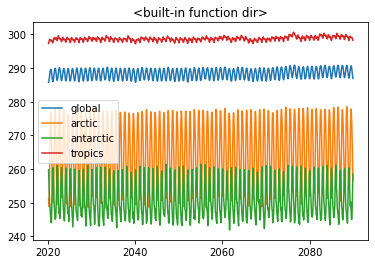

In [29]:
# test: 
file = G3_files[-2]
print(file)
eg = get_temps_ds_file(file)
for region in regions_dict.keys():
    plt.plot(eg.time, eg['tas_{}'.format(region)], label=region)
plt.legend()
plt.title(dir)
plt.savefig('Figures/testing/tas_check.jpg', dpi=250)

In [31]:
file_sets, labels = [G3_files, G4_files], ['G3', 'G4']

for i in [0, 1]:
    DF = pd.DataFrame()
    for file in tqdm(file_sets[i]): # 5 secs per it
        model, experiment, ensemble_member = file.split('_')[2], file.split('_')[3], file.split('_')[4]
        ds = get_temps_ds_file(file=file)
        df = pd.DataFrame({'Year':ds.time.dt.year.values,
                           'Month':ds.time.dt.month.values,
                           })
        for region in regions_dict.keys():
            label = 'tas_{}'.format(region)
            df[label] = ds[label].values
        df['Model'] = model
        df['Experiment'] = experiment
        df['Ensemble_member'] = ensemble_member
        DF = pd.concat([DF, df])
    DF.to_csv('processed_tas/GeoMIP_{}_tas_by_region.csv'.format(labels[i]))

 10%|█         | 1/10 [00:01<00:09,  1.04s/it]/home/users/a_duffey/.conda/envs/main/lib/python3.10/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'tas' has multiple fill values {b'1.e+20f', '1.e+20f'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/home/users/a_duffey/.conda/envs/main/lib/python3.10/site-packages/xarray/coding/variables.py:140: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  condition |= data == fv
/home/users/a_duffey/.conda/envs/main/lib/python3.10/site-packages/xarray/coding/variables.py:140: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  condition |= data == fv
/home/users/a_duffey/.conda/envs/main/lib/python3.10/site-packages/xarray/coding/variables.py:140: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform eleme

In [63]:
### now repeat for the ssp scenarios:
print('now repeat for the cmip historical and ssp scenarios:')

cmip_dirs = []
for model in G3G4_mods:
    for scenario in cmip5_scens:
        for x in glob.glob('/badc/cmip5/data/cmip5/*/*/{m}/{s}/mon/atmos/Amon/*p1/latest/tas/'.format(m=model, s=scenario)):
            cmip_dirs.append(x)

#for path in excluded_runs:
#    cmip_dirs = [s for s in cmip_dirs if not path in s]

#print(cmip_dirs)
cmip_dirs

now repeat for the cmip historical and ssp scenarios:


['/badc/cmip5/data/cmip5/output1/BNU/BNU-ESM/historical/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/BNU/BNU-ESM/piControl/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/BNU/BNU-ESM/rcp26/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/BNU/BNU-ESM/rcp45/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/BNU/BNU-ESM/rcp85/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/historical/mon/atmos/Amon/r1i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/historical/mon/atmos/Amon/r2i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/historical/mon/atmos/Amon/r3i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/historical/mon/atmos/Amon/r4i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/historical/mon/atmos/Amon/r5i1p1/latest/tas/',
 '/badc/cmip5/data/cmip5/output1/NASA-GISS/GISS-E2-R/his

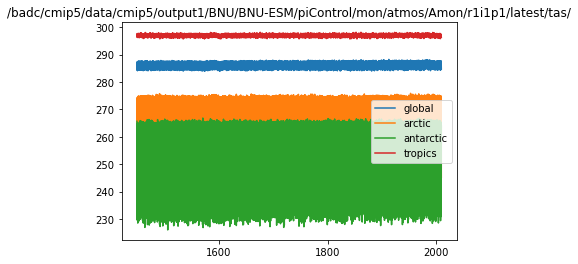

In [76]:
# test: 
dir = cmip_dirs[1]
eg = get_temps_ds(dir)
for region in regions_dict.keys():
    plt.plot(eg.time, eg['tas_{}'.format(region)], label=region)
plt.legend()
plt.title(dir)
plt.savefig('Figures/testing/tas_check.jpg', dpi=250)

In [81]:
cmip_dirs[25]

'/badc/cmip5/data/cmip5/output1/MOHC/HadGEM2-ES/piControl/mon/atmos/Amon/r1i1p1/latest/tas/'

In [82]:
os.listdir('/badc/cmip5/data/cmip5/output1/MOHC/HadGEM2-ES/piControl/mon/atmos/Amon/r1i1p1/latest/tas/')

['tas_Amon_HadGEM2-ES_piControl_r1i1p1_185912-188411.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_188412-190911.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_190912-193411.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_193412-195911.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_195912-198411.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_198412-200911.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_200912-203411.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_203412-205911.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_205912-208411.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_208412-209910.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_209812-212311.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_212312-214811.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_214812-217311.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_217312-219811.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_219812-222311.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_222312-224811.nc',
 'tas_Amon_HadGEM2-ES_piControl_r1i1p1_224812-227311.nc',
 'tas_Amon_Had

In [85]:
## runs a bit slower cause runs are longer
DF = pd.DataFrame()
for dir in tqdm(cmip_dirs):
    model, experiment, ensemble_member = dir.split('/')[7], dir.split('/')[8], dir.split('/')[12]
    print(model, experiment, ensemble_member)
    ds = get_temps_ds(dir=dir)
    df = pd.DataFrame({'Year':ds.time.dt.year.values,
                       'Month':ds.time.dt.month.values,
                       })
    for region in regions_dict.keys():
        label = 'tas_{}'.format(region)
        df[label] = ds[label].values
    df['Model'] = model
    df['Experiment'] = experiment
    df['Ensemble_member'] = ensemble_member
    DF = pd.concat([DF, df])
DF.to_csv('processed_tas/CMIP5_scens_tas_by_region.csv')

  0%|          | 0/86 [00:00<?, ?it/s]

BNU-ESM historical r1i1p1


  1%|          | 1/86 [00:00<01:08,  1.25it/s]

BNU-ESM piControl r1i1p1


  2%|▏         | 2/86 [00:04<03:06,  2.22s/it]

...

 98%|█████████▊| 84/86 [03:15<00:06,  3.37s/it]

NorESM1-M rcp45 r1i1p1


 99%|█████████▉| 85/86 [03:19<00:03,  3.52s/it]

NorESM1-M rcp85 r1i1p1


100%|██████████| 86/86 [03:20<00:00,  2.33s/it]


In [20]:
### repeat for CSIRO, fow which i manually uploaded the files:
CSIRO_CMIP_dirs = os.listdir('/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/')
CSIRO_CMIP_dirs = [x for x in CSIRO_CMIP_dirs if '11-50' not in x] # lose the short overlapping segment of picontrol
CSIRO_CMIP_files = ['/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/'+x for x in CSIRO_CMIP_dirs]
CSIRO_CMIP_files

['/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/tas_Amon_CSIRO-Mk3L-1-2_piControl_r1i1p1_000101-100012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/tas_Amon_CSIRO-Mk3L-1-2_rcp45_r1i2p1_200601-230012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/tas_Amon_CSIRO-Mk3L-1-2_rcp45_r2i2p1_200601-230012.nc',
 '/gws/nopw/j04/cpom/aduffey/GeoMIP/CSIRO-Mk3L-1-2/monthly/tas_Amon_CSIRO-Mk3L-1-2_rcp45_r3i2p1_200601-230012.nc']

In [25]:
DF = pd.read_csv('processed_tas/CMIP5_scens_tas_by_region.csv')

for file in tqdm(CSIRO_CMIP_files):
    model, experiment, ensemble_member = file.split('_')[2],file.split('_')[3], file.split('_')[4]
    print(model, experiment, ensemble_member)
    ds = get_temps_ds_file(file=file)
    df = pd.DataFrame({'Year':ds.time.dt.year.values,
                       'Month':ds.time.dt.month.values,
                       })
    for region in regions_dict.keys():
        label = 'tas_{}'.format(region)
        df[label] = ds[label].values
    df['Model'] = model
    df['Experiment'] = experiment
    df['Ensemble_member'] = ensemble_member
    DF = pd.concat([DF, df])
    
DF.to_csv('processed_tas/CMIP5_scens_tas_by_region.csv')

  0%|          | 0/4 [00:00<?, ?it/s]

CSIRO-Mk3L-1-2 piControl r1i1p1


 25%|██▌       | 1/4 [00:02<00:07,  2.38s/it]

CSIRO-Mk3L-1-2 rcp45 r1i2p1


 50%|█████     | 2/4 [00:03<00:02,  1.46s/it]

CSIRO-Mk3L-1-2 rcp45 r2i2p1


 75%|███████▌  | 3/4 [00:04<00:01,  1.16s/it]

CSIRO-Mk3L-1-2 rcp45 r3i2p1


100%|██████████| 4/4 [00:04<00:00,  1.20s/it]
